In [3]:
import pandas as pd

event_data = pd.read_csv(
    "../data/processed/tesla_event_dataset.csv"
)

event_data.head()

,event_id,event_name,event_type,event_date,day,Date,Close,return_from_day_0,SPY_Close,SPY_return_from_day_0,abnormal_return
0,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,0,2023-01-24,143.889999,0.000000,382.664886,0.000000,0.000000
1,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,1,2023-01-25,144.429993,0.375282,382.808258,0.037467,0.337815
2,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,2,2023-01-26,160.270004,11.383699,387.015381,1.136894,10.246805
3,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,3,2023-01-27,177.899994,23.636107,387.904724,1.369302,22.266805
4,TSLA_001,Q4 2022 Earnings,Earnings,2023-01-25,4,2023-01-30,166.660004,15.824591,383.037750,0.097439,15.727153


In [4]:
event_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_id               138 non-null    str    
 1   event_name             138 non-null    str    
 2   event_type             138 non-null    str    
 3   event_date             138 non-null    str    
 4   day                    138 non-null    int64  
 5   Date                   138 non-null    str    
 6   Close                  138 non-null    float64
 7   return_from_day_0      138 non-null    float64
 8   SPY_Close              138 non-null    float64
 9   SPY_return_from_day_0  138 non-null    float64
 10  abnormal_return        138 non-null    float64
dtypes: float64(5), int64(1), str(5)
memory usage: 12.0 KB


In [5]:
event_summary = event_data[event_data["day"] == 5][
    ["event_id", "event_name", "event_type", "abnormal_return"]
]

event_summary.head()

,event_id,event_name,event_type,abnormal_return
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424
11,TSLA_002,Q1 2023 Earnings,Earnings,-10.863438
17,TSLA_003,Q4 2023 Earnings,Earnings,-9.635181
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670
29,TSLA_005,Cybertruck Unveiled,Product Launch,-7.457915


In [6]:
event_summary = event_data[event_data["day"] == 5][
    ["event_id", "event_name", "event_type", "abnormal_return"]
]

event_summary.head()

,event_id,event_name,event_type,abnormal_return
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424
11,TSLA_002,Q1 2023 Earnings,Earnings,-10.863438
17,TSLA_003,Q4 2023 Earnings,Earnings,-9.635181
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670
29,TSLA_005,Cybertruck Unveiled,Product Launch,-7.457915


In [7]:
event_summary.shape

(23, 4)

In [8]:
event_summary = event_summary.sort_values(
    "abnormal_return",
    ascending=False
)

event_summary

,event_id,event_name,event_type,abnormal_return
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670
89,TSLA_015,5-for-1 Stock Split Announced,Corporate Action,28.703411
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424
65,TSLA_011,Major Price Reductions Across Key Models,Pricing Strategy,11.798452
53,TSLA_009,Global Vehicle Price Cuts,Pricing Strategy,8.251983
137,TSLA_023,Autopilot Recall Affecting Over 2 Million Vehi...,Recall,5.798085
101,TSLA_017,Shareholders Approve Elon Musk Pay Package,Corporate Action,1.372317
35,TSLA_006,Model S Plaid Delivery Event,Product Launch,0.907980
59,TSLA_010,Further US Price Cuts,Pricing Strategy,-0.831565
125,TSLA_021,Touchscreen Recall (NHTSA),Recall,-0.984186


In [9]:
event_summary["absolute_abnormal_return"] = event_summary["abnormal_return"].abs()

In [10]:
event_summary = event_summary.sort_values(
    "absolute_abnormal_return",
    ascending=False
)

event_summary 

,event_id,event_name,event_type,abnormal_return,absolute_abnormal_return
23,TSLA_004,Q1 2024 Earnings,Earnings,34.537670,34.537670
89,TSLA_015,5-for-1 Stock Split Announced,Corporate Action,28.703411,28.703411
5,TSLA_001,Q4 2022 Earnings,Earnings,18.814424,18.814424
77,TSLA_013,AI Day 2022,Technology Announcement,-14.084529,14.084529
65,TSLA_011,Major Price Reductions Across Key Models,Pricing Strategy,11.798452,11.798452
11,TSLA_002,Q1 2023 Earnings,Earnings,-10.863438,10.863438
17,TSLA_003,Q4 2023 Earnings,Earnings,-9.635181,9.635181
119,TSLA_020,Mexico Gigafactory Announced,Factory Expansion,-9.257418,9.257418
83,TSLA_014,"Robotaxi (""We, Robot"") Event",Technology Announcement,-9.074922,9.074922
95,TSLA_016,3-for-1 Stock Split Announced,Corporate Action,-8.534494,8.534494


In [11]:
import matplotlib.pyplot as plt

In [12]:
average_by_type_day = (
    event_data
    .groupby(["event_type", "day"])["abnormal_return"]
    .mean()
    .reset_index()
)

average_by_type_day.head()

,event_type,day,abnormal_return
0,Corporate Action,0,0.000000
1,Corporate Action,1,-2.009922
2,Corporate Action,2,1.190585
3,Corporate Action,3,3.680940
4,Corporate Action,4,4.302571


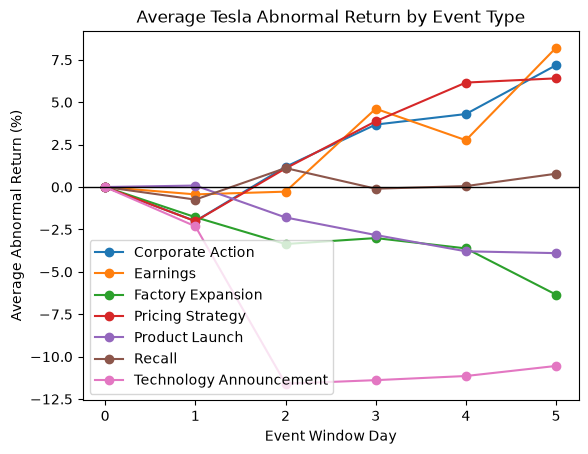

In [13]:
for event_type in average_by_type_day["event_type"].unique():

    data = average_by_type_day[
        average_by_type_day["event_type"] == event_type
    ]

    plt.plot(
        data["day"],
        data["abnormal_return"],
        marker="o",
        label=event_type
    )

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Event Window Day")
plt.ylabel("Average Abnormal Return (%)")
plt.title("Average Tesla Abnormal Return by Event Type")

plt.legend()
plt.show()

In [14]:
event_data["absolute_abnormal_return"] = event_data["abnormal_return"].abs()

In [15]:
average_magnitude_by_type_day = (
    event_data
    .groupby(["event_type", "day"])["absolute_abnormal_return"]
    .mean()
    .reset_index()
)

average_magnitude_by_type_day.head()

,event_type,day,absolute_abnormal_return
0,Corporate Action,0,0.000000
1,Corporate Action,1,3.823544
2,Corporate Action,2,4.934117
3,Corporate Action,3,8.691967
4,Corporate Action,4,8.323230


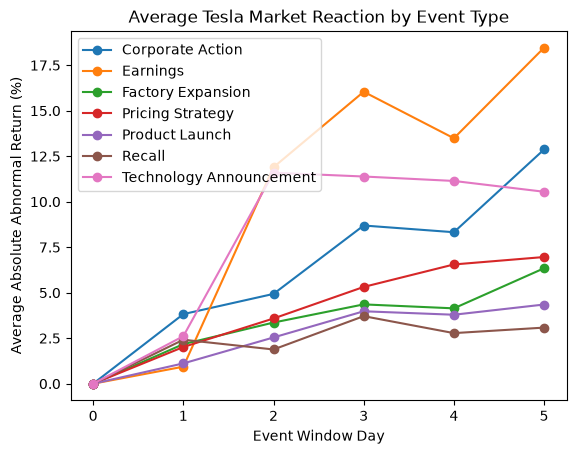

In [16]:
for event_type in average_magnitude_by_type_day["event_type"].unique():

    data = average_magnitude_by_type_day[
        average_magnitude_by_type_day["event_type"] == event_type
    ]

    plt.plot(
        data["day"],
        data["absolute_abnormal_return"],
        marker="o",
        label=event_type
    )

plt.xlabel("Event Window Day")
plt.ylabel("Average Absolute Abnormal Return (%)")
plt.title("Average Tesla Market Reaction by Event Type")

plt.legend()
plt.show()